# 04 - Génération des masques d'entraînement

**Objectif :** convertir les 125 pièces annotées (4 tracés) en masques
d'entraînement pour le futur U-Net, et vérifier visuellement que la technique
retenue (masque intérieur + masque frontière) sépare correctement les pièces
qui se touchent.

**Rappel de la technique :** un U-Net avec une seule sortie binaire (pièce/fond)
fusionnerait deux pièces adjacentes en une seule tache. On entraîne donc le
modèle à prédire 2 canaux — l'intérieur de chaque pièce (rétrécie) et sa
frontière — pour pouvoir les séparer ensuite par soustraction.

**Sortie de ce notebook :** le dossier `data/processed/masks/` rempli avec,
pour chaque tracé, l'image et ses 2 masques (utilisables directement pour
entraîner le modèle en Phase 3).


In [1]:
import sys
sys.path.append('../src')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from acquisition.pdf_loader import rasterize_pdf, get_pdf_page_size_cm
from segmentation.dataset_prep import generate_masks, masks_to_instances, save_masks

REFERENCE_DIR = Path('../data/raw/reference')
ANNOTATIONS_DIR = Path('../data/processed')
MASKS_DIR = Path('../data/processed/masks')

TRACEES = ['Tracee1', 'Tracee2', 'Tracee3', 'Tracee4']

## 1. Génération des masques pour les 4 tracés

Chaque masque est généré à 1536px de côté maximum (au lieu de la pleine
résolution ~4000px) — un compromis volontaire pour que l'entraînement reste
gérable en mémoire, tout en gardant largement assez de précision pour une
tolérance de ±3cm.

In [2]:
all_masks = {}

for name in TRACEES:
    pdf_path = str(REFERENCE_DIR / f'{name}.pdf')
    ann_path = str(ANNOTATIONS_DIR / f'{name}_annotations.json')

    img = rasterize_pdf(pdf_path, dpi=100)
    w_cm, h_cm = get_pdf_page_size_cm(pdf_path)
    h_px, w_px = img.shape[:2]
    scale_orig = ((w_cm / w_px) + (h_cm / h_px)) / 2

    masks = generate_masks(img, ann_path, scale_orig, target_max_dim=1536)
    save_masks(masks, str(MASKS_DIR))
    all_masks[name] = masks

    print(f"{name}: {masks.image.shape[1]}x{masks.image.shape[0]} px, "
          f"{masks.n_pieces} pieces, echelle {masks.scale_cm_per_px:.4f} cm/px "
          f"-> sauvegarde dans {MASKS_DIR}/")

Tracee1: 1536x951 px, 25 pieces, echelle 0.1320 cm/px -> sauvegarde dans ..\data\processed\masks/
Tracee2: 1536x928 px, 40 pieces, echelle 0.1641 cm/px -> sauvegarde dans ..\data\processed\masks/
Tracee3: 1227x1536 px, 23 pieces, echelle 0.1046 cm/px -> sauvegarde dans ..\data\processed\masks/
Tracee4: 1522x1536 px, 37 pieces, echelle 0.0968 cm/px -> sauvegarde dans ..\data\processed\masks/


## 2. Vérification : les masques séparent-ils bien toutes les pièces ?

Contrôle purement géométrique (indépendant de tout modèle) : on reconstruit les
instances à partir des masques et on vérifie que leur nombre correspond
exactement au nombre de pièces annotées. Si ce n'est pas le cas pour un tracé,
il faut ajuster les paramètres (érosion, épaisseur de frontière) avant
d'entraîner quoi que ce soit.

In [3]:
print(f"{'Tracé':10s} {'Pièces annotées':18s} {'Instances séparées':20s} {'Résultat'}")
print("-" * 65)

for name, masks in all_masks.items():
    labels, n_instances = masks_to_instances(masks.mask_interieur, masks.mask_frontiere, min_area_px=150)
    ok = n_instances == masks.n_pieces
    print(f"{name:10s} {masks.n_pieces:<18d} {n_instances:<20d} {'OK' if ok else 'ECART A CORRIGER'}")
    assert ok, f"{name}: le nombre d'instances ne correspond pas, ajuster les parametres de generate_masks()"

print("\nTous les tracés : le nombre d'instances correspond exactement au nombre de pièces annotées.")

Tracé      Pièces annotées    Instances séparées   Résultat
-----------------------------------------------------------------
Tracee1    25                 25                   OK
Tracee2    40                 40                   OK
Tracee3    23                 23                   OK
Tracee4    37                 37                   OK

Tous les tracés : le nombre d'instances correspond exactement au nombre de pièces annotées.


## 3. Inspection visuelle (les 4 tracés)

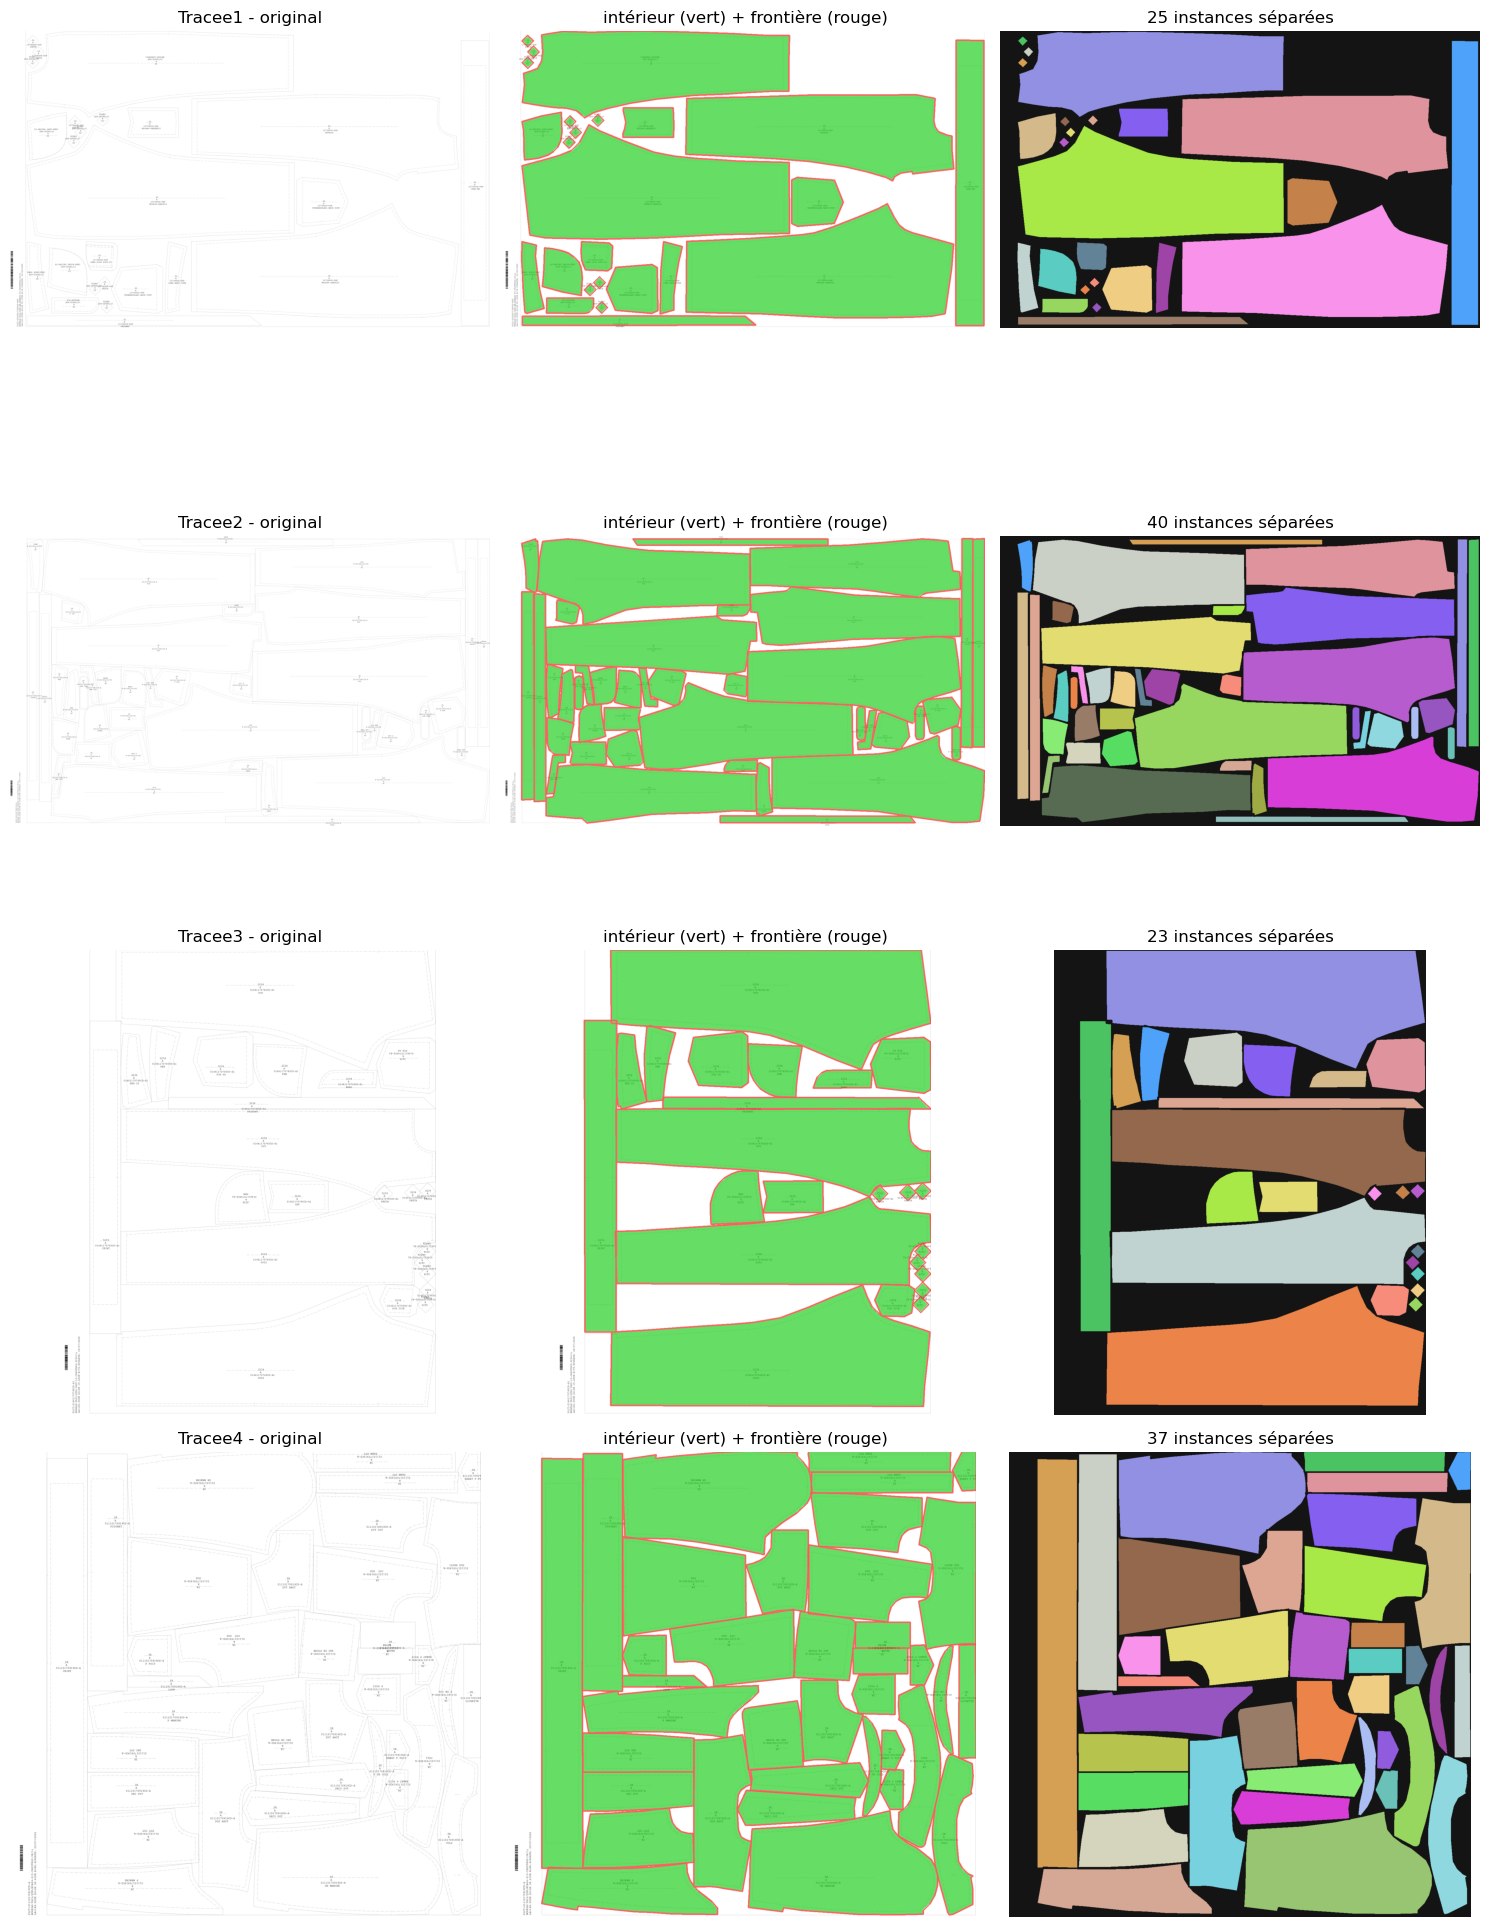

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

for row, (name, masks) in enumerate(all_masks.items()):
    img_rgb = cv2.cvtColor(masks.image, cv2.COLOR_BGR2RGB)

    overlay = masks.image.copy()
    overlay[masks.mask_interieur > 0] = [0, 200, 0]
    overlay[masks.mask_frontiere > 0] = [0, 0, 255]
    blend = cv2.addWeighted(masks.image, 0.4, overlay, 0.6, 0)
    blend_rgb = cv2.cvtColor(blend, cv2.COLOR_BGR2RGB)

    labels, n_instances = masks_to_instances(masks.mask_interieur, masks.mask_frontiere, min_area_px=150)
    rng = np.random.default_rng(42)
    colors = rng.integers(60, 255, size=(n_instances + 1, 3))
    colors[0] = [20, 20, 20]
    colored = colors[labels].astype(np.uint8)

    axes[row, 0].imshow(img_rgb); axes[row, 0].set_title(f'{name} - original'); axes[row, 0].axis('off')
    axes[row, 1].imshow(blend_rgb); axes[row, 1].set_title('intérieur (vert) + frontière (rouge)'); axes[row, 1].axis('off')
    axes[row, 2].imshow(colored); axes[row, 2].set_title(f'{n_instances} instances séparées'); axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('../data/processed/04_verification_masques_4_tracees.png', dpi=80)
plt.show()

## Prochaines étapes

1. Augmentation de données (Phase 2) — rotations, échelle, luminosité, bruit —
   pour compenser le peu d'images sources
2. Architecture et entraînement du U-Net (Phase 3), avec la stratégie
   leave-one-tracé-out pour la validation
3. Extraction des points de contour à partir des masques prédits (Phase 5),
   pour rebrancher sur `measure_piece()` et `evaluate_tracee()`
